This cell executes a command to check the status of the NVIDIA GPU. It's an important first step in many machine learning projects to ensure that the hardware is correctly recognized and ready for accelerated computations.

In [ ]:

!nvidia-smi

Sat Nov  2 14:26:44 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   33C    P8               9W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

This command unzips a file named runs.zip, which contains data and pre-trained weights needed for the YOLO model.

In [ ]:
!unzip runs.zip

Archive:  runs.zip
   creating: runs/
   creating: runs/detect/
   creating: runs/detect/predict5/
  inflating: runs/detect/predict5/4edit.jpg  
   creating: runs/detect/predict7/
  inflating: runs/detect/predict7/6edit.jpg  
   creating: runs/detect/predict/
  inflating: runs/detect/predict/S075_002_00000012_png.rf.048ed2b9754f79821bcef8f7b9a8678c.jpg  
  inflating: runs/detect/predict/S138_004_00000012_png.rf.4153e9a363a1dda925a3ad9165abefd4.jpg  
  inflating: runs/detect/predict/S059_001_00000018_png.rf.9f079249cb4c443d169296edebc3342e.jpg  
  inflating: runs/detect/predict/S108_005_00000020_png.rf.51a24a0ea17bcfb7bd7b18682d5b83f2.jpg  
  inflating: runs/detect/predict/S100_006_00000014_png.rf.cded7b123fb713a15a667f02434ecdc7.jpg  
  inflating: runs/detect/predict/S076_005_00000011_png.rf.dd695c1f8c8b9ee9a4ab492a5a7eb95a.jpg  
  inflating: runs/detect/predict/S069_002_00000013_png.rf.5cebf47a19264595b2f1af2848a625a2.jpg  
  inflating: runs/detect/predict/S032_005_00000014_png.rf.f62

This cell installs the ultralytics library, which is the framework used to implement the YOLO (You Only Look Once) model for object detection.

In [ ]:

!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.0/879.0 kB 27.7 MB/s eta 0:00:00


This cell imports the ultralytics library and runs a system check. This step is crucial for verifying that the environment is correctly set up and all dependencies are met.

In [ ]:

import ultralytics
ultralytics.checks()

Ultralytics 8.3.27 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 32.3/112.6 GB disk)


This cell imports the YOLO class from the ultralytics library, which is the main class for building and using YOLO models. It also imports the Image class from IPython.display to display images within the notebook.

In [ ]:

from ultralytics import YOLO
from IPython.display import Image

This cell outputs the local file path where the downloaded dataset is stored. This path is used in subsequent cells to access the dataset for training.

In [ ]:
dataset.location

'/content/emotion-detection-4'

This command initiates the training process for a YOLO model. It uses the yolo command-line tool with several arguments:

task=detect: Specifies that the task is object detection.

mode=train: Sets the mode to training.

data={dataset.location}/data.yaml: Points to the data configuration file in the downloaded dataset directory.

model="yolo11n.pt": Specifies the base model to use.

epochs=50: Sets the number of training iterations to 75.

imgsz=640: Sets the image size for training. The output shows the training progress, including loss metrics (box_loss, cls_loss, dfl_loss) and performance metrics (mAP50, mAP50-95), which indicate how well the model is learning to detect objects and classify them.

In [ ]:
!yolo task=detect mode=train data={dataset.location}/data.yaml model="yolo11n.pt" epochs=50 imgsz=640

Ultralytics 8.3.27 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/content/emotion-detection-4/data.yaml, epochs=75, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=Tru

Cell 9-11: These cells display three different images generated as part of the training process:

confusion_matrix.png: Shows how well the model's predictions align with the true labels, providing insight into which emotions it might be confusing with one another.

labels.jpg: Visualizes the bounding boxes and labels from the training dataset.

results.png: Provides a graphical summary of the model's performance throughout the training epochs, including metrics like precision, recall, and mean average precision (mAP).

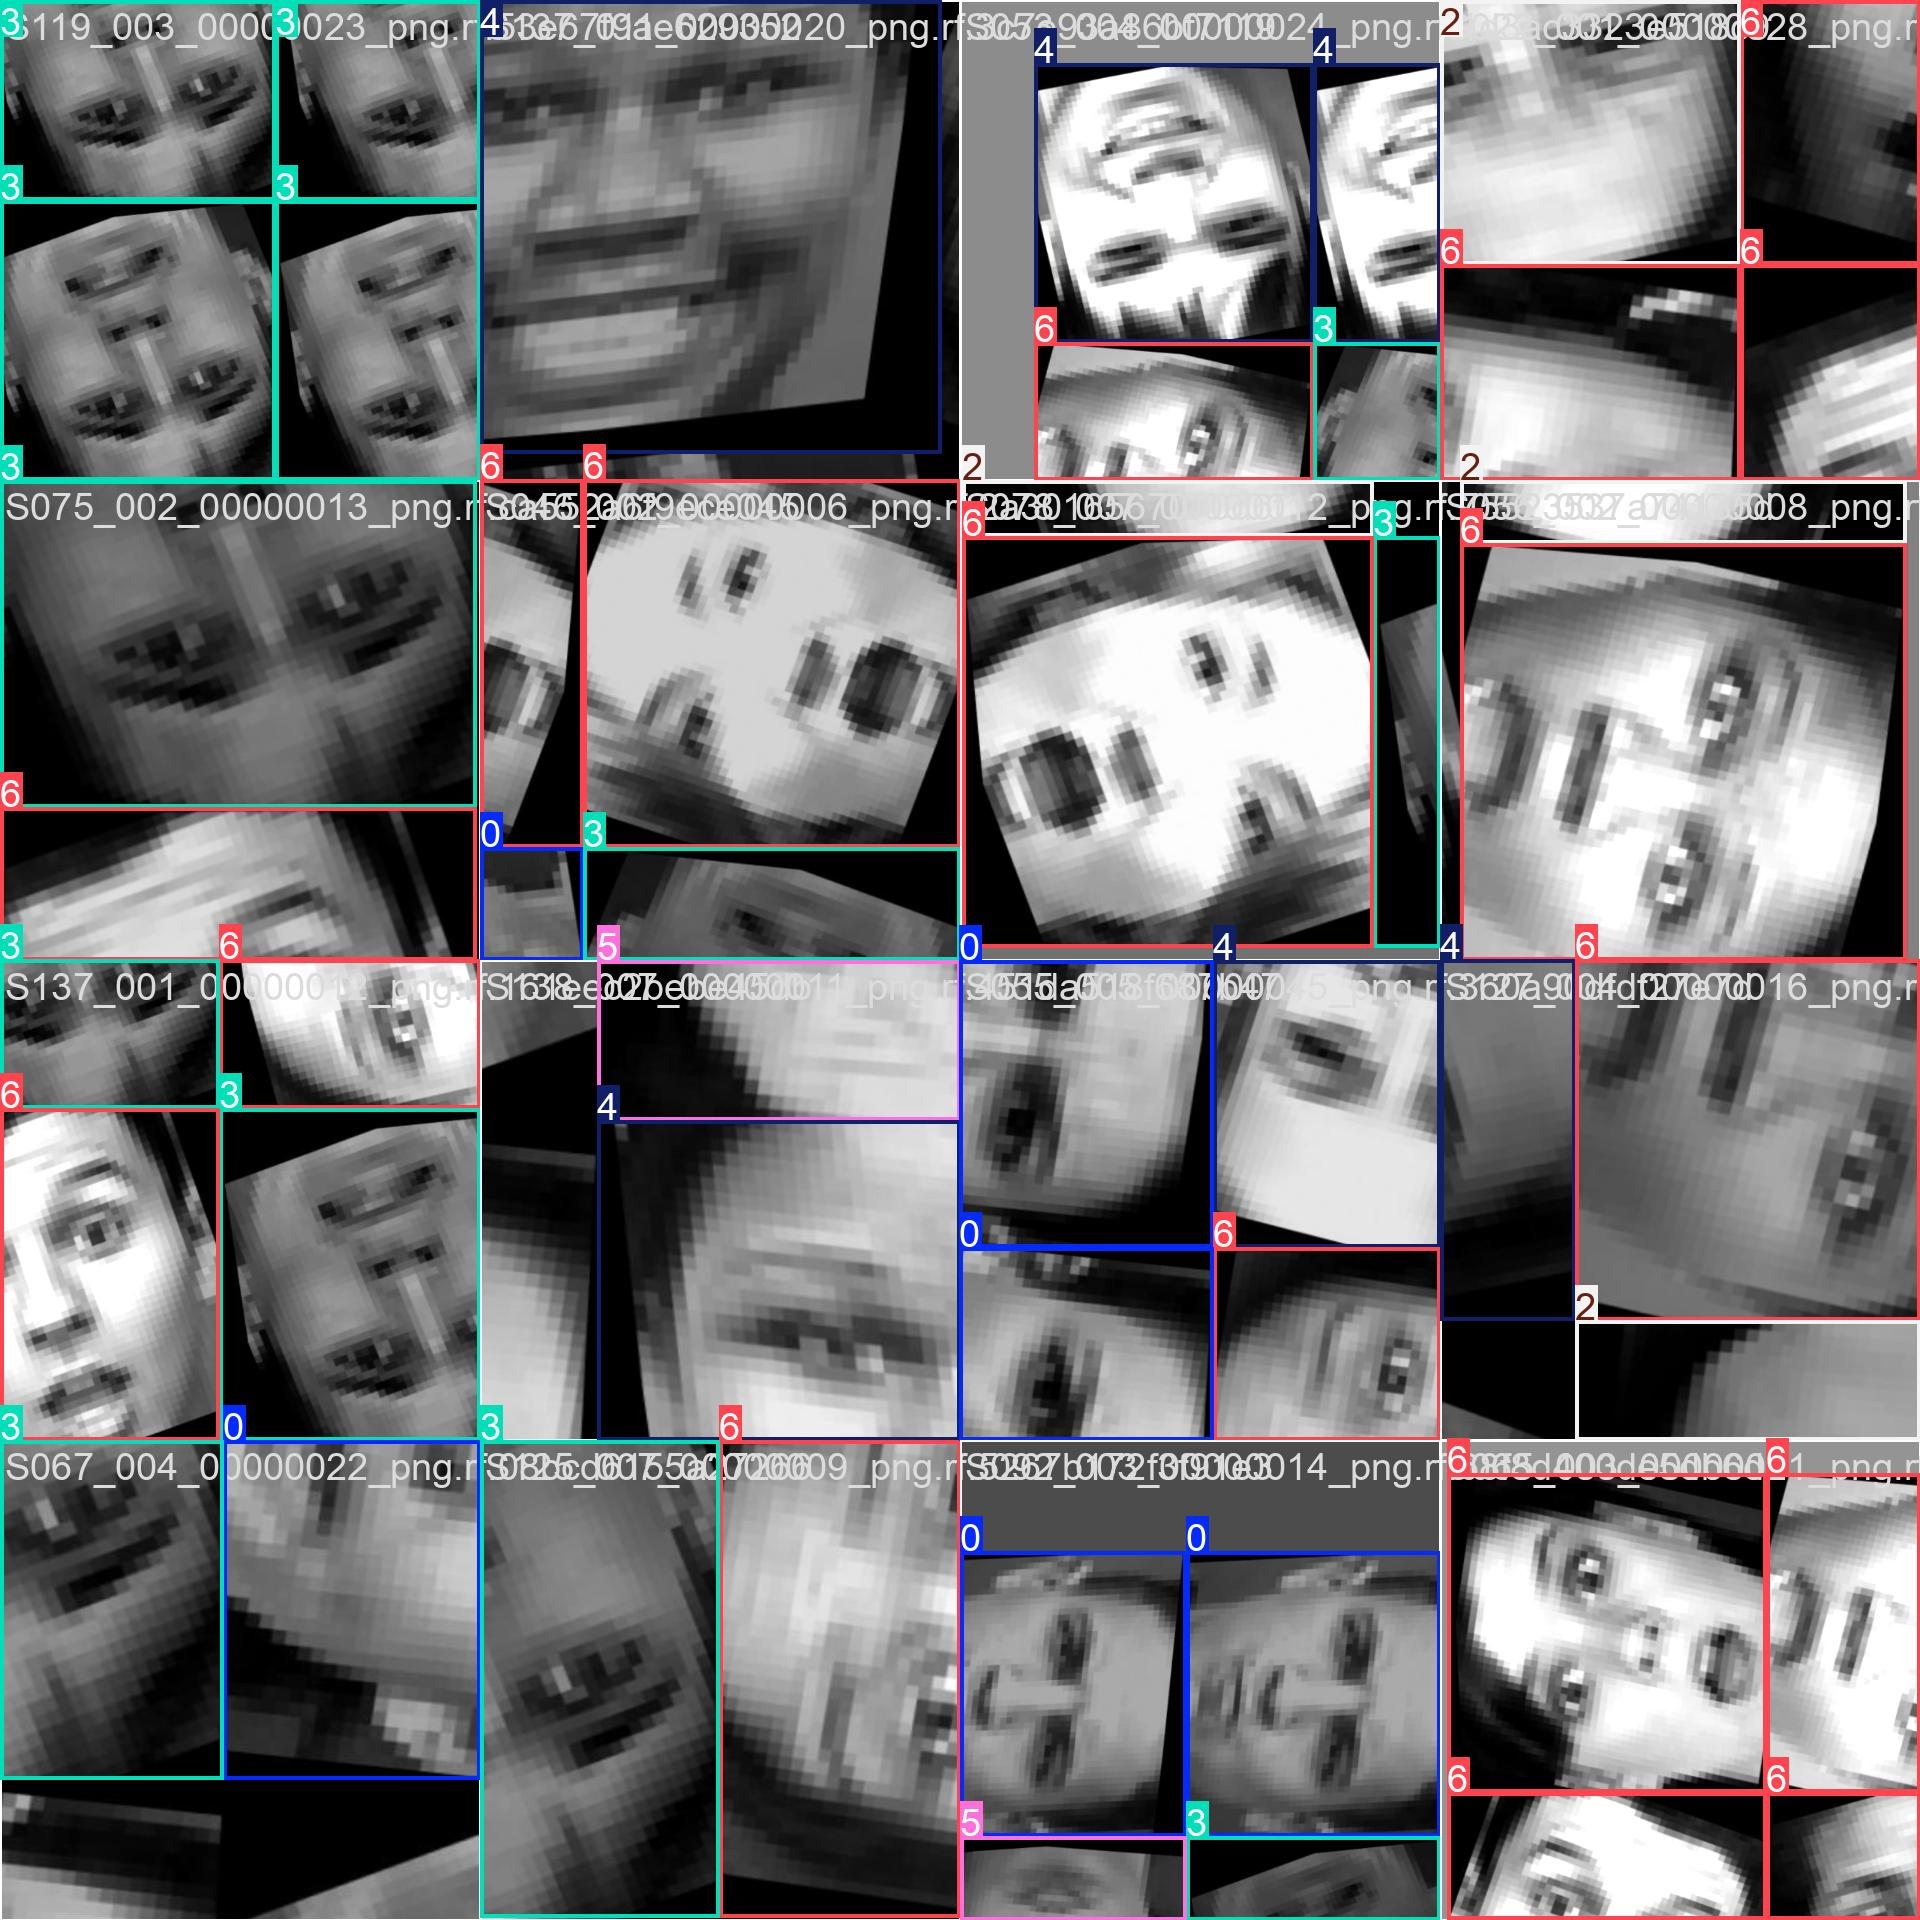

In [ ]:
Image("/content/runs/detect/train2/train_batch0.jpg", width=600)

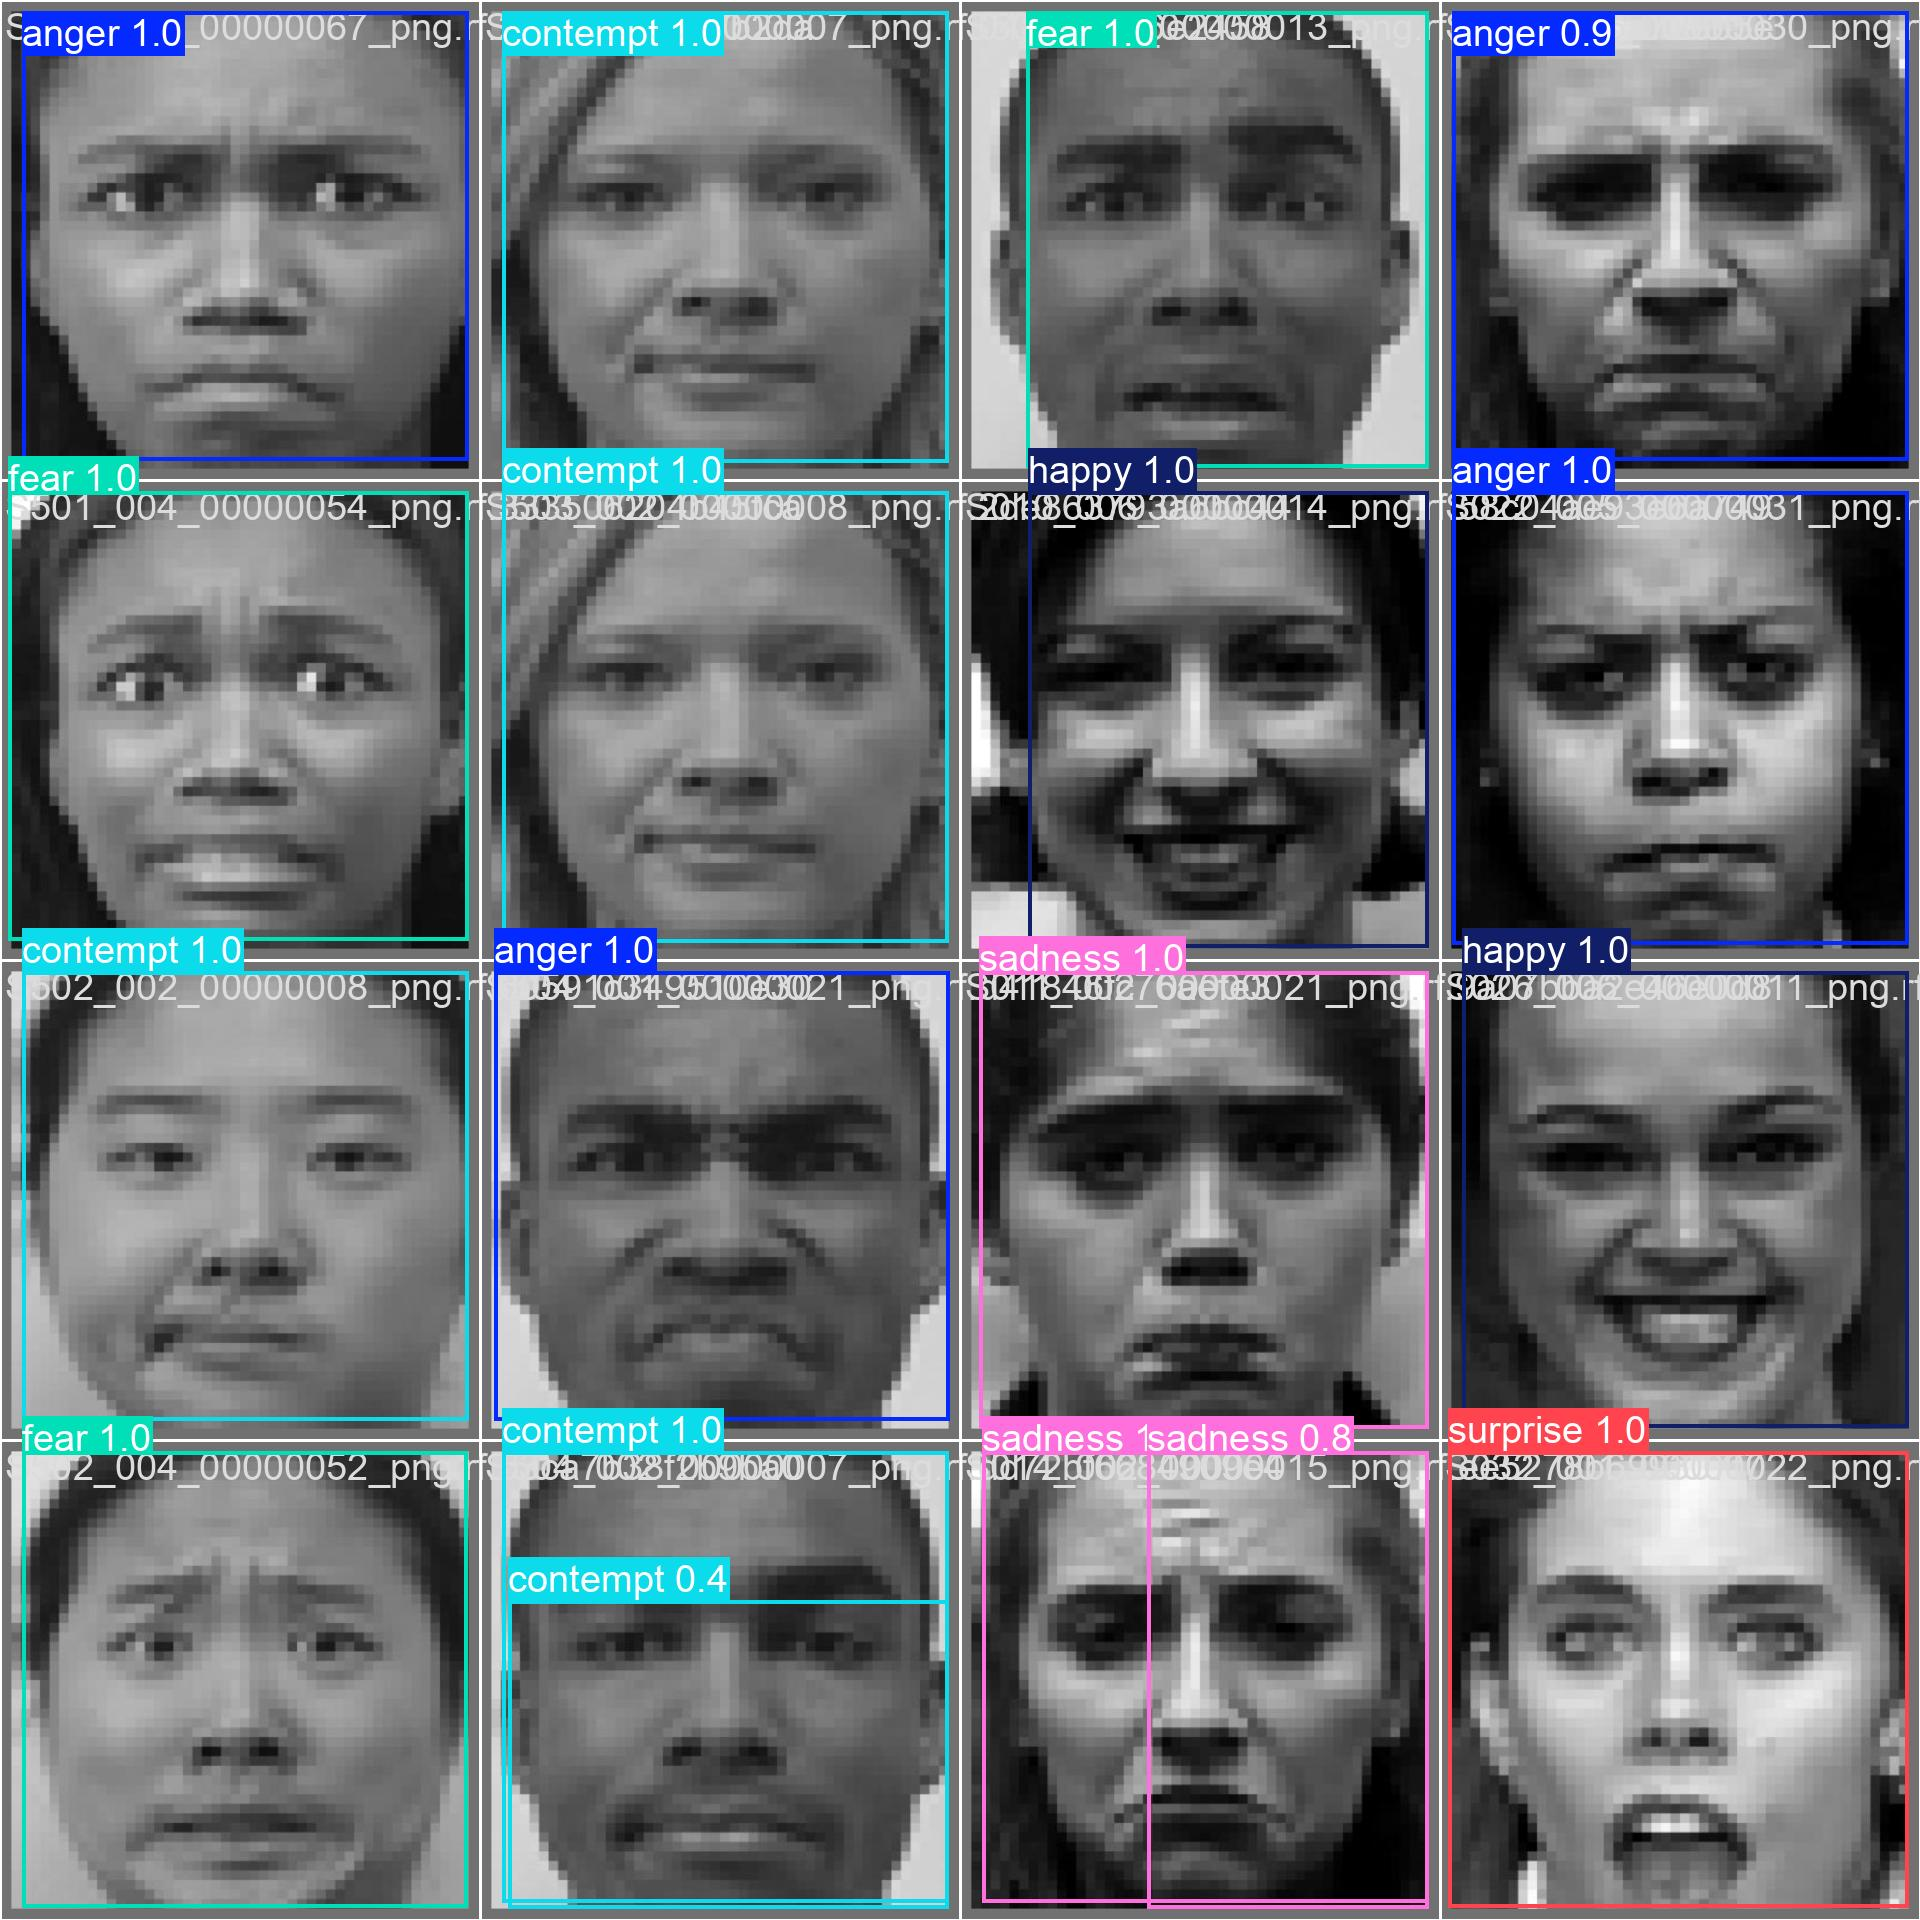

In [ ]:

Image("/content/runs/detect/train2/val_batch0_pred.jpg", width=600)

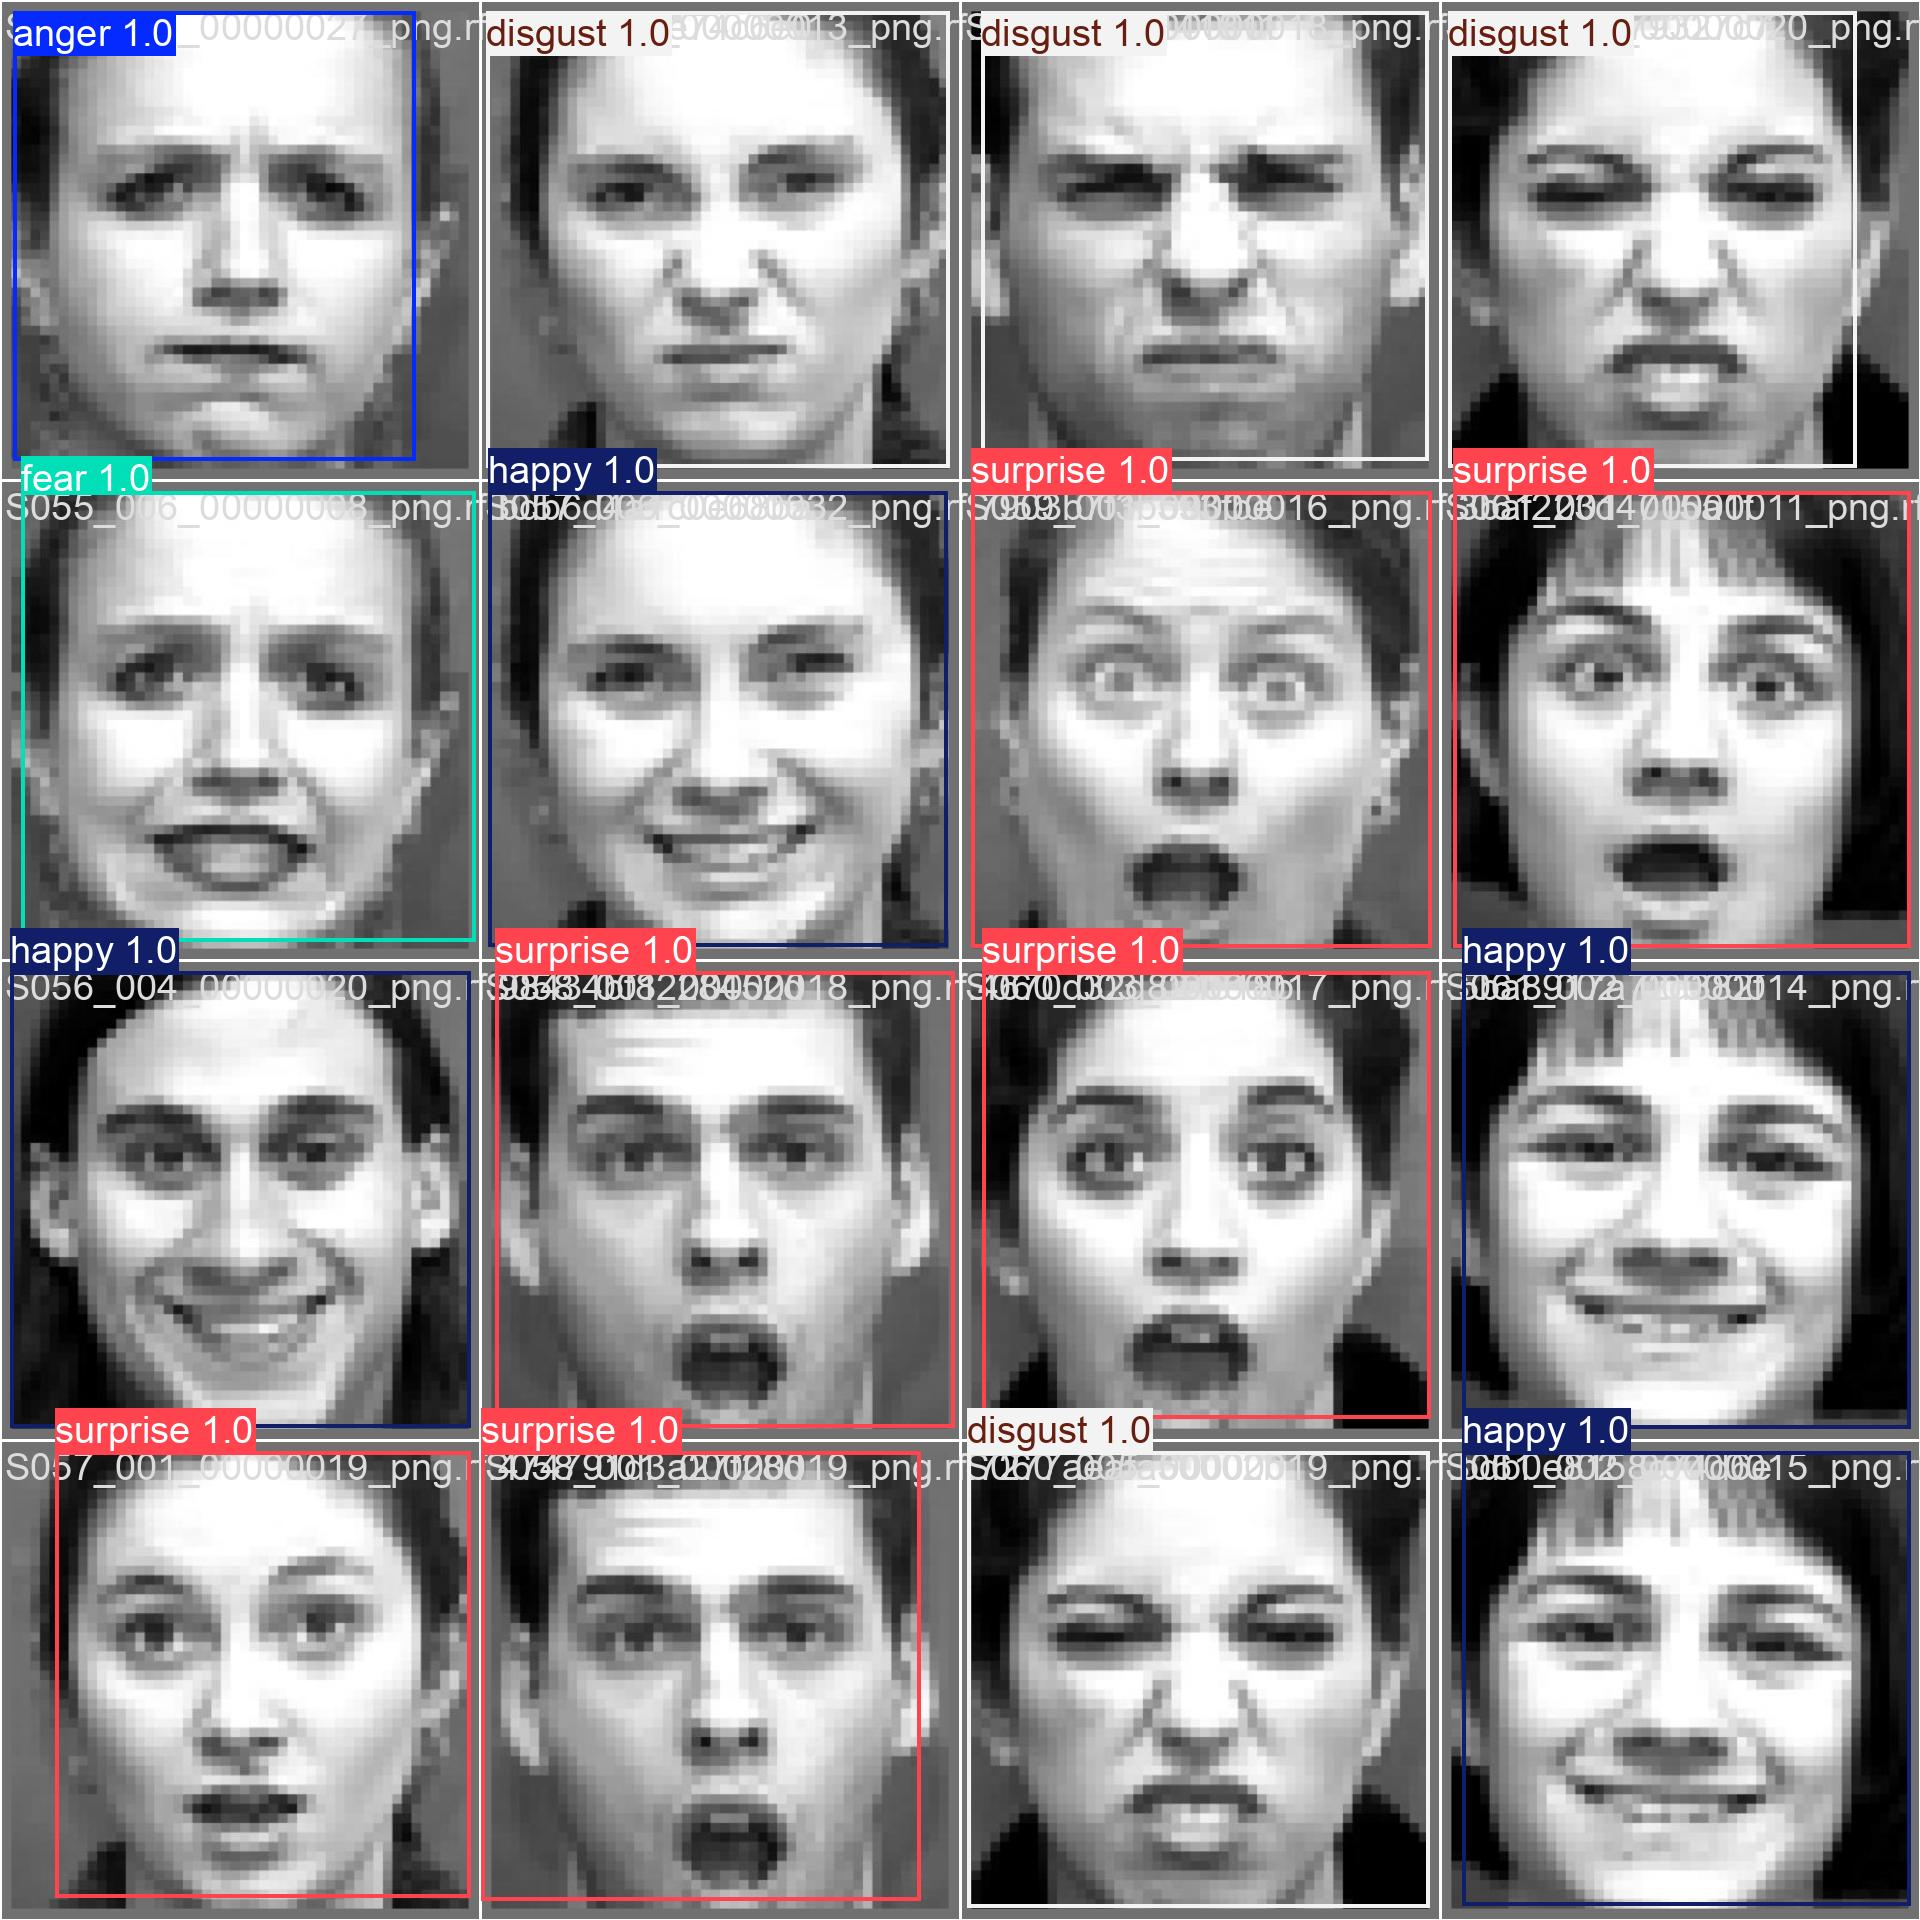

In [ ]:

Image("/content/runs/detect/train2/val_batch1_pred.jpg", width=600)


In [ ]:
!yolo task=detect mode=predict model="/content/runs/detect/train2/weights/best.pt" conf=0.25 source={dataset.location}/test/images save=True


Ultralytics 8.3.27 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11n summary (fused): 238 layers, 2,583,517 parameters, 0 gradients, 6.3 GFLOPs

image 1/99 /content/emotion-detection-4/test/images/S010_006_00000013_png.rf.2a4455df3a6749235491cd7dee3ec5e3.jpg: 640x640 1 happy, 11.5ms
image 2/99 /content/emotion-detection-4/test/images/S011_003_00000014_png.rf.a630b3d60b38bdce8966fba4207bca2d.jpg: 640x640 3 fears, 17.3ms
image 3/99 /content/emotion-detection-4/test/images/S011_004_00000021_png.rf.af9a70a66ca5f6c0e28c75d03b48df3d.jpg: 640x640 1 anger, 15.8ms
image 4/99 /content/emotion-detection-4/test/images/S011_006_00000012_png.rf.54bf3a5083ef0cf065296fe6026d0cf1.jpg: 640x640 1 happy, 15.5ms
image 5/99 /content/emotion-detection-4/test/images/S014_003_00000028_png.rf.86baa8a5791996ec793a93edaad73e8a.jpg: 640x640 1 anger, 11.4ms
image 6/99 /content/emotion-detection-4/test/images/S014_005_00000015_png.rf.862e01fd0b74ad92cea70e67df6da3fa.jpg: 640x640 1 happy, 13.1ms


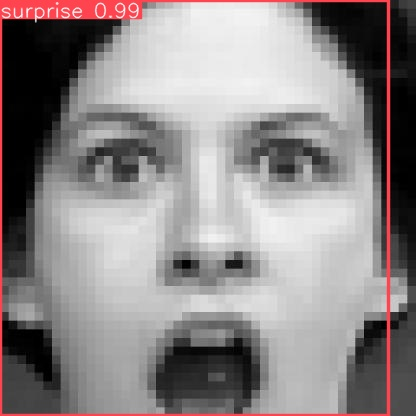

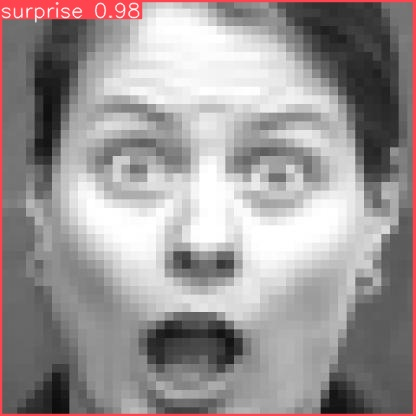

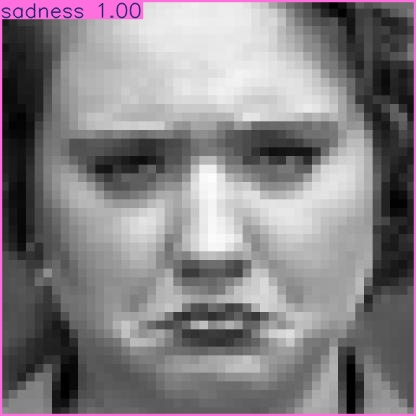

In [ ]:

import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob('/content/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[1:4]:
    display(IPyImage(filename=img, width=600))
    print("\n")

In [ ]:
!yolo task=detect mode=predict model= "/content/runs/detect/train2/weights/best.pt" conf=0.25 source=7edit.jpg save=True

Ultralytics 8.3.27 🚀 Python-3.10.12 torch-2.5.0+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLO11n summary (fused): 238 layers, 2,583,517 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/7edit.jpg: 640x640 1 contempt, 10.2ms
Speed: 5.4ms preprocess, 10.2ms inference, 544.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict9
💡 Learn more at https://docs.ultralytics.com/modes/predict


Ultralytics 8.3.27 🚀 Python-3.10.12 torch-2.4.1+cu121 CPU (Intel Xeon 2.20GHz)
YOLO11n summary (fused): 238 layers, 2,583,517 parameters, 0 gradients, 6.3 GFLOPs

image 1/1 /content/3edit.jpg: 640x640 1 surprise, 215.3ms
Speed: 7.4ms preprocess, 215.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict13
💡 Learn more at https://docs.ultralytics.com/modes/predict


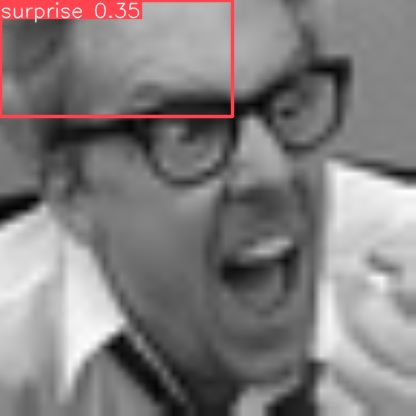

In [12]:
# Perform prediction on a single image and display
single_image_path = "3edit.jpg"  # Update this with the path to your single image
!yolo task=detect mode=predict model={model_path} conf=0.25 source={single_image_path} save=True
#output_image_path = os.path.join(latest_folder, "2edit.jpg")  # Adjust the output path as needed
display(Image("/content/runs/detect/predict11/3edit.jpg", width=600))